<a href="https://colab.research.google.com/github/OmarFarukNoman/Into-to-Machine-Learning/blob/main/Final%20Project/Project(Intro_to_ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


Mounted at /content/drive


In [ ]:
# Path to your file in Google Drive
csv_path = "/content/drive/My Drive/Intro to ML/Project/RT_IOT2022.csv"

# Load the dataset
dataset = pd.read_csv(csv_path)

**Dataset Information**

In [ ]:

# Features and target
X = dataset.drop(columns=["Attack_type"])
y = dataset["Attack_type"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Make y a 1D Series for convenience
y = y.squeeze()                   # becomes a Series named 'Attack_type'
print("\nFirst 5 target values (raw):")
print(y.head())

# Combine into one DataFrame like Social_Network_Ads example
dataset = pd.concat([X, y.rename("Attack_type")], axis=1)

# ===============================
# 2. Tables for presentation
# ===============================

# Table 1: shapes
shape_table = pd.DataFrame({
    "Object": ["X (features)", "y (target)"],
    "Shape": [str(X.shape), str(y.shape)],
    "No. of samples": [X.shape[0], y.shape[0]],
    "No. of features": [X.shape[1], 1]
})
print("\nTable 1 – Dataset shapes:")
display(shape_table)

# Table 2: first 5 target values
targets_table = y.head().reset_index()
targets_table.columns = ["Index", "Attack_type"]
print("\nTable 2 – First 5 target values:")
display(targets_table)

# (optional) also show first few rows of full dataset
print("\nFirst 5 rows of the dataset:")
display(dataset.head())

X shape: (123117, 84)
y shape: (123117,)

First 5 target values (raw):
0    MQTT_Publish
1    MQTT_Publish
2    MQTT_Publish
3    MQTT_Publish
4    MQTT_Publish
Name: Attack_type, dtype: object

Table 1 – Dataset shapes:


,Object,Shape,No. of samples,No. of features
0,X (features),"(123117, 84)",123117,84
1,y (target),"(123117,)",123117,1



Table 2 – First 5 target values:


,Index,Attack_type
0,0,MQTT_Publish
1,1,MQTT_Publish
2,2,MQTT_Publish
3,3,MQTT_Publish
4,4,MQTT_Publish



First 5 rows of the dataset:


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


Dataset shape (rows, columns): (123117, 85)

Column data types:
Unnamed: 0                int64
id.orig_p                 int64
id.resp_p                 int64
proto                    object
service                  object
                         ...   
idle.std                float64
fwd_init_window_size      int64
bwd_init_window_size      int64
fwd_last_window_size      int64
Attack_type              object
Length: 85, dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  

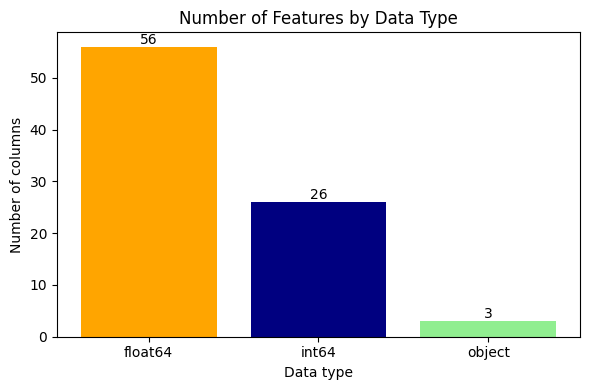

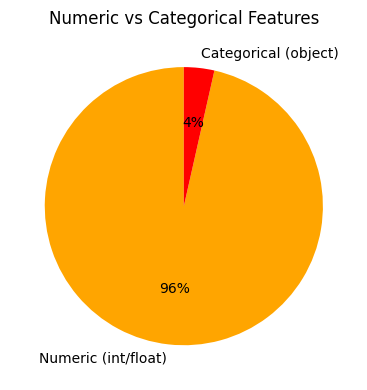

In [ ]:
print("Dataset shape (rows, columns):", dataset.shape)

print("\nColumn data types:")
print(dataset.dtypes)

print("\nInfo:")
print(dataset.info())

# --- Visual 1: Bar chart of data types ---

# Count how many columns of each pandas dtype
dtype_counts = dataset.dtypes.value_counts()

# Choose colors for each dtype (edit these as you like)
dtype_counts = dataset.dtypes.value_counts()

dtype_color_map = {
    'float64': 'orange',
    'int64': 'navy',
    'object': 'lightgreen'
}
colors = [dtype_color_map.get(str(dt), 'gray') for dt in dtype_counts.index]

plt.figure(figsize=(6, 4))

# Use numeric positions for x
x = np.arange(len(dtype_counts))

bars = plt.bar(x, dtype_counts.values, color=colors)
plt.title('Number of Features by Data Type')
plt.xlabel('Data type')
plt.ylabel('Number of columns')

# Set string labels at those positions
plt.xticks(x, dtype_counts.index)

# --- Add values above each bar ---
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()



# --- Visual 2: Pie chart numeric vs categorical ---

# --- Visual 2: Pie chart numeric vs categorical ---

num_numeric = dataset.select_dtypes(include=[np.number]).shape[1]
num_categorical = dataset.select_dtypes(exclude=[np.number]).shape[1]

feature_type_counts = pd.Series(
    [num_numeric, num_categorical],
    index=['Numeric (int/float)', 'Categorical (object)']
)

# >>> Choose your colors here <<<
numeric_color = 'orange'
categorical_color = 'red'
pie_colors = [numeric_color, categorical_color]

plt.figure(figsize=(4, 4))
feature_type_counts.plot(
    kind='pie',
    autopct='%1.0f%%',
    startangle=90,
    colors=pie_colors
)
plt.title('Numeric vs Categorical Features')
plt.ylabel('')  # hide y-label
plt.tight_layout()
plt.show()

# ---- Summary of features / target, missing values & incomplete rows/cols ----

# Separate features (X) and target (y) from the combined dataset
X_features = dataset.drop(columns=["Attack_type"])
y_target = dataset["Attack_type"]

total_rows = dataset.shape[0]
total_features = X_features.shape[1]
total_target = y_target.shape[0]


**Preprocessing**

In [ ]:
# Missing values
missing_features = X_features.isna().sum().sum()   # total missing values in all feature columns
missing_target = y_target.isna().sum()             # missing values in target column

# Incomplete rows / columns (at least one missing value)
incomplete_rows = dataset.isna().any(axis=1).sum()   # rows with >=1 missing value
incomplete_cols = dataset.isna().any(axis=0).sum()   # columns with >=1 missing value

print("\nDataset Summary:")
print(f"Total number of features (X): {total_features}")
print(f"Total number of samples: {total_target}")
print(f"Missing values in features (X): {missing_features}")
print(f"Missing values in target (y): {missing_target}")
print(f"Number of incomplete rows (any missing value): {incomplete_rows}")
print(f"Number of incomplete columns (any missing value): {incomplete_cols}")

print("\nNumber of missing (NA) values per column:")
print(dataset.isna().sum().sort_values(ascending=False))



Dataset Summary:
Total number of features (X): 84
Total number of samples: 123117
Missing values in features (X): 0
Missing values in target (y): 0
Number of incomplete rows (any missing value): 0
Number of incomplete columns (any missing value): 0

Number of missing (NA) values per column:
Unnamed: 0              0
id.orig_p               0
id.resp_p               0
proto                   0
service                 0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 85, dtype: int64


In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns
print("\nCategorical feature columns:")
print(list(cat_cols))

for col in cat_cols:
    print(f"\nValue counts for '{col}':")
    print(X[col].value_counts())



Categorical feature columns:
['proto', 'service']

Value counts for 'proto':
proto
tcp     110427
udp      12633
icmp        57
Name: count, dtype: int64

Value counts for 'service':
service
-         102861
dns         9753
mqtt        4132
http        3464
ssl         2663
ntp          121
dhcp          50
irc           43
ssh           28
radius         2
Name: count, dtype: int64


In [ ]:
# One-hot encode any categorical features in X
X_encoded = pd.get_dummies(X, drop_first=True)

# Label-encode the multiclass target Attack_type
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Encoded feature matrix shape:", X_encoded.shape)
print("Number of classes:", len(class_names))
print("Class names:", class_names)

# ----- Show how categorical -> numerical (for proto & service) -----
# original categorical columns
print("Original categorical columns (first 5 rows):")
print(X[['proto', 'service']].head())

# find the new dummy columns created for proto and service
proto_cols   = [c for c in X_encoded.columns if c.startswith('proto_')]
service_cols = [c for c in X_encoded.columns if c.startswith('service_')]

print("\nDummy-encoded columns for proto & service (first 5 rows):")
print(X_encoded[proto_cols + service_cols].head())

# (Optional) show side-by-side original + encoded for first 5 rows
print("\nOriginal vs encoded (first 5 rows):")
print(pd.concat(
    [X[['proto', 'service']].head(),
     X_encoded[proto_cols + service_cols].head()],
    axis=1
))


# ----- Show how categorical -> numerical (compact demo for slides) -----

# Original categorical columns (first 5 rows)
print("Original categorical columns (first 5 rows):")
print(X[['proto', 'service']].head())

# Find dummy columns created for proto and service
proto_cols   = [c for c in X_encoded.columns if c.startswith('proto_')]
service_cols = [c for c in X_encoded.columns if c.startswith('service_')]

# Pick just a few dummy columns to show in the slide
demo_proto_cols   = proto_cols[:2]      # e.g., proto_tcp, proto_udp
demo_service_cols = service_cols[:3]    # e.g., service_mqtt, service_http, ...

demo_cols = demo_proto_cols + demo_service_cols

# 1) Original + boolean dummies (True/False)
example_bool = pd.concat(
    [X[['proto', 'service']].head(5),
     X_encoded[demo_cols].head(5)],
    axis=1
)

print("\n (categorical → one-hot, True/False):")
print(example_bool.to_string(index=False))

# 2) Same dummy columns shown as 0/1
example_num = example_bool.copy()
example_num[demo_cols] = example_num[demo_cols].astype(int)

print("\n With dummy columns as 0/1:")
print(example_num.to_string(index=False))

Encoded feature matrix shape: (123117, 93)
Number of classes: 12
Class names: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']
Original categorical columns (first 5 rows):
  proto service
0   tcp    mqtt
1   tcp    mqtt
2   tcp    mqtt
3   tcp    mqtt
4   tcp    mqtt

Dummy-encoded columns for proto & service (first 5 rows):
   proto_tcp  proto_udp  service_dhcp  service_dns  service_http  service_irc  \
0       True      False         False        False         False        False   
1       True      False         False        False         False        False   
2       True      False         False        False         False        False   
3       True      False         False        False         False        False   
4       True      False         False        False         False        False   

   service_mqtt  se

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=0,
    stratify=y_encoded
)

# Create a scaler object
sc = StandardScaler()

# Fit the scaler to the training data and transform
X_train_std = sc.fit_transform(X_train)

# Apply the scaler to the test data
X_test_std = sc.transform(X_test)

# After you have X_train, X_test, X_train_std, X_test_std

total_samples  = X_encoded.shape[0]
n_features     = X_encoded.shape[1]
train_samples  = X_train_std.shape[0]
val_samples    = X_test_std.shape[0]

print(f"Total dataset size   : {total_samples} samples")
print(f"Training sample size : {train_samples} samples "
      f"({train_samples/total_samples:.1%} of data)")
print(f"Validation sample size: {val_samples} samples "
      f"({val_samples/total_samples:.1%} of data)")


# X_train_std and X_test_std already computed above

# Convert the scaled array back to a DataFrame so we can inspect it easily
X_train_std_df = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)

# Pick just a few features to show in the slide (e.g., first 5 numeric features)
demo_cols = X_train.columns[:5]

# 1) Show original vs scaled values for first 5 samples
demo_original = X_train[demo_cols].head(5)
demo_scaled   = X_train_std_df[demo_cols].head(5)

print("\nFeature values BEFORE scaling (first 5 rows):")
print(demo_original.to_string(index=False))

print("\nFeature values AFTER StandardScaler (first 5 rows):")
print(demo_scaled.round(2).to_string(index=False))

# 2) Show mean and std before vs after scaling (for the same features)
print("\nMean and std BEFORE scaling:")
print(X_train[demo_cols].agg(['mean', 'std']))

print("\nMean and std AFTER StandardScaler (should be ~0 mean, ~1 std):")
print(X_train_std_df[demo_cols].agg(['mean', 'std']).round(3))


Total dataset size   : 123117 samples
Training sample size : 98493 samples (80.0% of data)
Validation sample size: 24624 samples (20.0% of data)

Feature values BEFORE scaling (first 5 rows):
 Unnamed: 0  id.orig_p  id.resp_p  flow_duration  fwd_pkts_tot
      57204       7567         21       0.000004             1
      13450      16292         21       0.000004             1
       3086      54964         53       0.020099             2
      31827      34740         21       0.000004             1
       3875      36184         53       0.000072             1

Feature values AFTER StandardScaler (first 5 rows):
 Unnamed: 0  id.orig_p  id.resp_p  flow_duration  fwd_pkts_tot
       0.66      -1.42      -0.19          -0.03         -0.05
      -0.77      -0.96      -0.19          -0.03         -0.05
      -1.11       1.07      -0.18          -0.03         -0.01
      -0.17       0.01      -0.19          -0.03         -0.05
      -1.09       0.08      -0.18          -0.03         -0.05


Numeric feature columns:
['Unnamed: 0', 'id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_pkts_payload.std', 'flow_pkts_payload.min', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.min', 'fwd_iat.max', 'fwd_

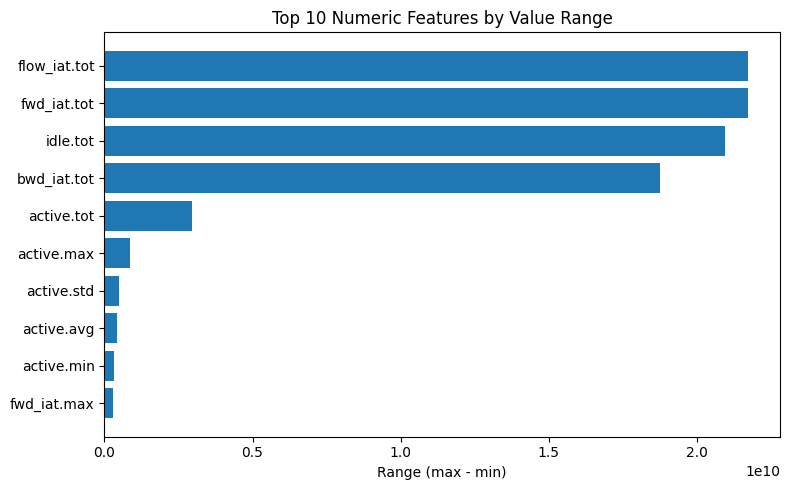

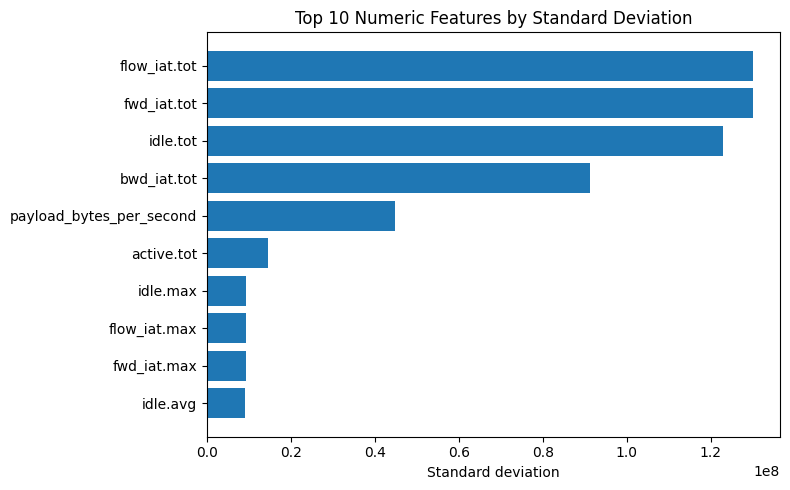

In [ ]:
numeric_cols = X.select_dtypes(include=[np.number]).columns
print("\nNumeric feature columns:")
print(list(numeric_cols))

print("\nDescriptive statistics for numeric features:")
stats_df = X[numeric_cols].describe().T     # 81 × 8 table
print(stats_df)

print("\nFeature ranges (min–max) for each numeric column:")
for col in numeric_cols:
    col_min = X[col].min()
    col_max = X[col].max()
    print(f"{col}: min = {col_min}, max = {col_max}")
# Add a "range" column: max - min
stats_df["range"] = stats_df["max"] - stats_df["min"]

# ============================
# 1) Top 10 features by range
# ============================
top_range = stats_df.sort_values("range", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_range.index, top_range["range"])
plt.title("Top 10 Numeric Features by Value Range")
plt.xlabel("Range (max - min)")
plt.gca().invert_yaxis()   # largest range at top
plt.tight_layout()
plt.show()

# ============================
# 2) Top 10 features by std
# ============================
top_std = stats_df.sort_values("std", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_std.index, top_std["std"])
plt.title("Top 10 Numeric Features by Standard Deviation")
plt.xlabel("Standard deviation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
Q1 = X[numeric_cols].quantile(0.25)
Q3 = X[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X[numeric_cols] < (Q1 - 1.5 * IQR)) | \
               (X[numeric_cols] > (Q3 + 1.5 * IQR))

print("\nApproximate number of outliers per numeric feature (IQR rule):")
print(outlier_mask.sum())



Approximate number of outliers per numeric feature (IQR rule):
Unnamed: 0                  0
id.orig_p                   0
id.resp_p               28452
flow_duration           19171
fwd_pkts_tot            17662
                        ...  
idle.avg                 5697
idle.std                 1017
fwd_init_window_size    28458
bwd_init_window_size    10359
fwd_last_window_size    28458
Length: 82, dtype: int64


**Logistic Regression**

Confusion matrix (raw counts):
[[ 1465     0     0     1     0     0     0     2     0     0    78     4]
 [    4    84     0     0     0     0     0     0    19     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    0     0     0   827     0     0     1     0     0     0     1     0]
 [    4     0     0     0     3     0     0     0     0     0     0     0]
 [    0     0     0     0     0     6     0     0     0     0     0     0]
 [    0     0     0     0     0     0   400     0     0     0     0     0]
 [    2     0     0     0     0     0     0   198     0     0     0     0]
 [   10     0     0     0     0     0     0     0   507     0     1     0]
 [    1     0     0     0     0     0     0     0     0   401     0     0]
 [   96     0     0     0     0     0     0     0     0     0  1526     0]
 [    1     0     0     0     0     0     2     0     0     0     9    39]]

Classification report:

                            precision    re

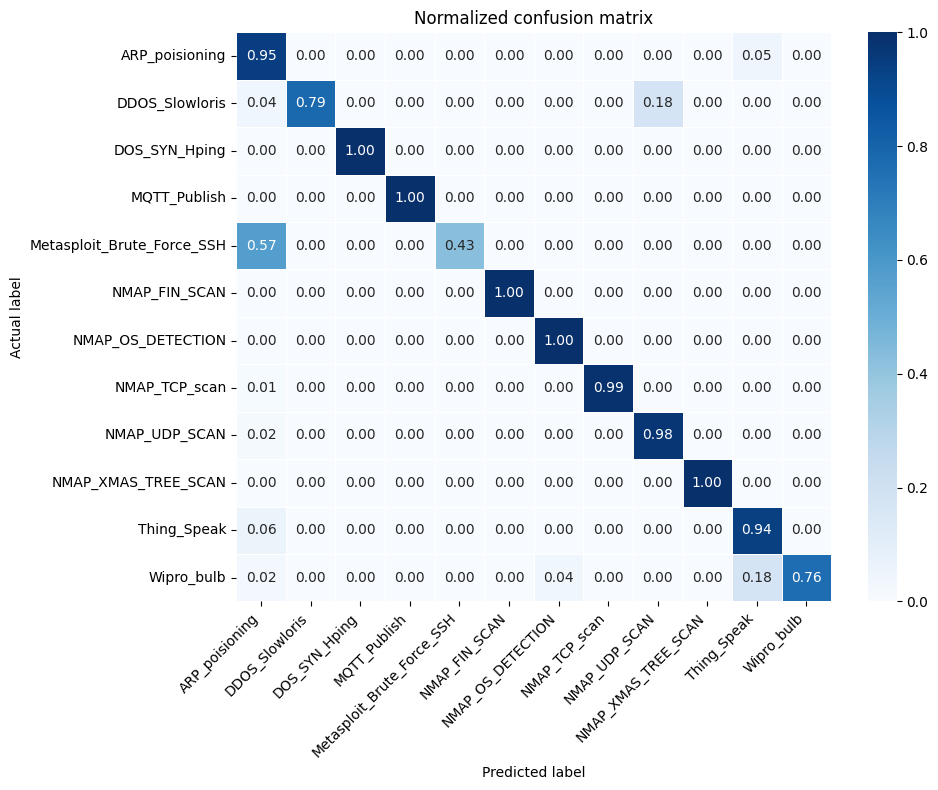


LogisticRegression (lbfgs) metrics on validation set:
  Accuracy : 0.9904
  Precision (macro): 0.9769
  Recall (macro)   : 0.9023
  F1-score (macro) : 0.9285


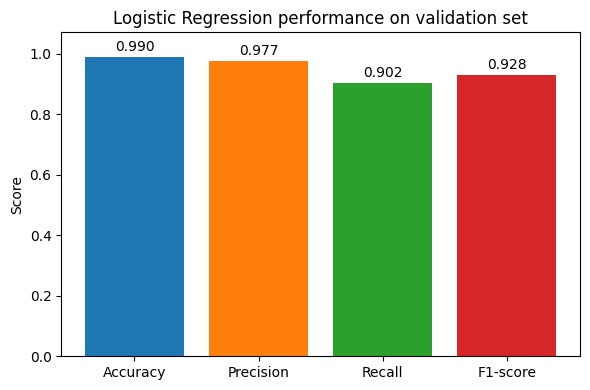


Cross-validation accuracy (Logistic Regression, 5-fold):
  Mean accuracy: 0.9913
  Std  accuracy: 0.0007
  All fold accuracies: [0.99139051 0.99005036 0.99212119 0.9911871  0.99167445]

SGD-based logistic regression after training:
  Final training loss    : 0.0935
  Final validation loss  : 0.1118
  Final training accuracy: 0.9828
  Final validation accuracy: 0.9819


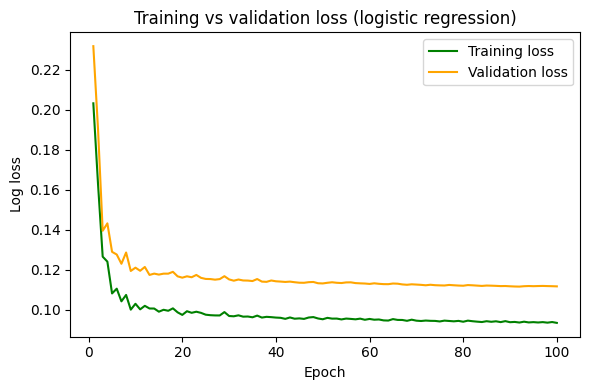

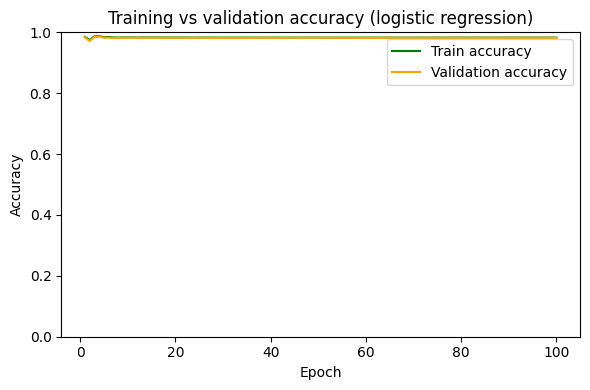

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, log_loss
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -------------------------------------------------
# 1. Train/test split + scaling
# -------------------------------------------------
test_size = 0.2       # 80/20 split
seed = 0

X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X_encoded, y_encoded,
    test_size=test_size,
    random_state=seed,
    stratify=y_encoded
)

sc2 = StandardScaler()
X_train2_std = sc2.fit_transform(X_train2)
X_test2_std  = sc2.transform(X_test2)

# -------------------------------------------------
# 2. LogisticRegression model
# -------------------------------------------------
model2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

model2.fit(X_train2_std, Y_train2)
predicted2 = model2.predict(X_test2_std)

# ---- Confusion matrix (raw) & classification report ----
cm = confusion_matrix(Y_test2, predicted2)
print("Confusion matrix (raw counts):")
print(cm)

print("\nClassification report:\n")
print(classification_report(Y_test2, predicted2, target_names=class_names))

# -------------------------------------------------
# 2a. Normalized confusion matrix plot (seaborn)
# -------------------------------------------------
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

plt.title("Normalized confusion matrix")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3. Final metrics bar chart (Accuracy, Precision, Recall, F1)
# -------------------------------------------------
acc  = accuracy_score(Y_test2, predicted2)
prec = precision_score(Y_test2, predicted2, average='macro', zero_division=0)
rec  = recall_score(Y_test2, predicted2, average='macro', zero_division=0)
f1   = f1_score(Y_test2, predicted2, average='macro', zero_division=0)

print(f"\nLogisticRegression (lbfgs) metrics on validation set:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision (macro): {prec:.4f}")
print(f"  Recall (macro)   : {rec:.4f}")
print(f"  F1-score (macro) : {f1:.4f}")

metrics_names  = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [acc, prec, rec, f1]

plt.figure(figsize=(6,4))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
bars = plt.bar(metrics_names, metrics_values, color=colors)

# give some extra space above the tallest bar
plt.ylim(0.0, max(metrics_values) + 0.08)

plt.ylabel("Score")
plt.title("Logistic Regression performance on validation set")

# add value labels on top of each bar
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,         # slightly above each bar
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3a. Cross-validation accuracy for Logistic Regression
# -------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

logreg_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        n_jobs=-1
    ))
])

cv_scores = cross_val_score(
    logreg_cv,
    X_encoded, y_encoded,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("\nCross-validation accuracy (Logistic Regression, 5-fold):")
print(f"  Mean accuracy: {cv_scores.mean():.4f}")
print(f"  Std  accuracy: {cv_scores.std():.4f}")
print(f"  All fold accuracies: {cv_scores}")

# -------------------------------------------------
# 4. Training & validation loss/accuracy over epochs (SGD LR)
#    using SGDClassifier with log_loss
# -------------------------------------------------
n_epochs = 100
classes = np.unique(Y_train2)

sgd_clf = SGDClassifier(
    loss="log_loss",      # logistic regression loss
    penalty="l2",
    learning_rate="optimal",
    random_state=0
)

train_losses, val_losses = [], []
train_accs,  val_accs  = [], []

for epoch in range(n_epochs):
    # partial_fit lets us iterate epoch by epoch
    if epoch == 0:
        sgd_clf.partial_fit(X_train2_std, Y_train2, classes=classes)
    else:
        sgd_clf.partial_fit(X_train2_std, Y_train2)

    # probabilities for log-loss
    y_train_proba = sgd_clf.predict_proba(X_train2_std)
    y_val_proba   = sgd_clf.predict_proba(X_test2_std)

    train_loss = log_loss(Y_train2, y_train_proba, labels=classes)
    val_loss   = log_loss(Y_test2, y_val_proba, labels=classes)

    train_acc = sgd_clf.score(X_train2_std, Y_train2)
    val_acc   = sgd_clf.score(X_test2_std, Y_test2)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

# Print final training / validation loss & accuracy
print("\nSGD-based logistic regression after training:")
print(f"  Final training loss    : {train_losses[-1]:.4f}")
print(f"  Final validation loss  : {val_losses[-1]:.4f}")
print(f"  Final training accuracy: {train_accs[-1]:.4f}")
print(f"  Final validation accuracy: {val_accs[-1]:.4f}")

epochs = np.arange(1, n_epochs + 1)

# Plot loss curves
plt.figure(figsize=(6,4))
plt.plot(epochs, train_losses, label="Training loss",color='green')
plt.plot(epochs, val_losses,   label="Validation loss",color='orange')
plt.xlabel("Epoch")
plt.ylabel("Log loss")
plt.title("Training vs validation loss (logistic regression)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot accuracy curves
plt.figure(figsize=(6,4))
plt.plot(epochs, train_accs, label="Train accuracy",color='green')
plt.plot(epochs, val_accs,   label="Validation accuracy",color=)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs validation accuracy (logistic regression)")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()


**Logistic Regression for different values of C**

C: 10
Training accuracy: 0.9933599342085224
Validation accuracy: 0.9916341780376868

C: 1
Training accuracy: 0.991989278425878
Validation accuracy: 0.9904158544509422

C: 0.1
Training accuracy: 0.9864965022895028
Validation accuracy: 0.9849740090968161

C: 0.001
Training accuracy: 0.9795619993299016
Validation accuracy: 0.9782326185834957



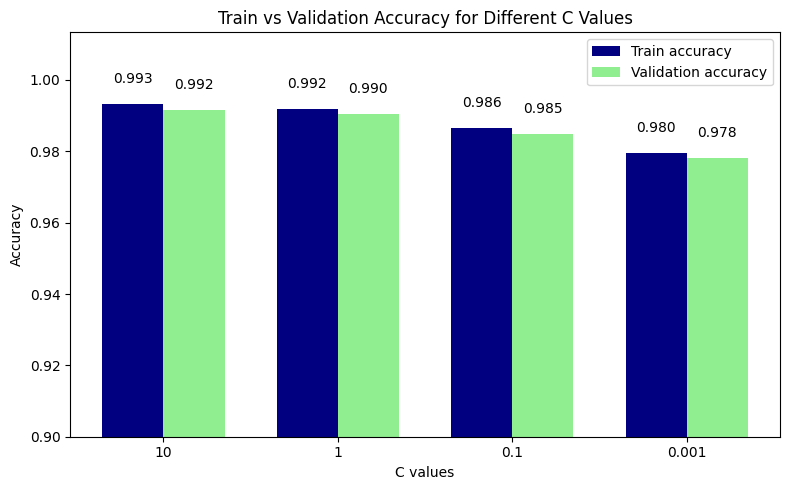

In [ ]:
C_list = [10, 1, 0.1, 0.001]

train_acc = []
test_acc = []

for c in C_list:
    clf = LogisticRegression(
        penalty='l2',      # L2 is much faster for this size
        C=c,
        solver='lbfgs',    # good general-purpose solver
        max_iter=1000,
        n_jobs=-1          # use all cores
    )
    clf.fit(X_train_std, y_train)

    tr = clf.score(X_train_std, y_train)
    te = clf.score(X_test_std, y_test)

    train_acc.append(tr)
    test_acc.append(te)

    print("C:", c)
    print("Training accuracy:", tr)
    print("Validation accuracy:", te)
    print("")

# ---------- Bar plot ----------
x = np.arange(len(C_list))  # positions for groups
width = 0.35

train_color = "navy"
test_color  = "lightgreen"

plt.figure(figsize=(8, 5))

bars_train = plt.bar(x - width/2, train_acc, width,
                     label='Train accuracy', color=train_color)
bars_test  = plt.bar(x + width/2, test_acc,  width,
                     label='Validation accuracy', color=test_color)

plt.xticks(x, C_list)
plt.xlabel('C values')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy for Different C Values')

# give some space above tallest bar
top = max(train_acc + test_acc) + 0.02
plt.ylim(0.9, top)

# add value labels ABOVE each bar
for bar in bars_train:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.005,                 # a bit above the bar
             f"{h:.3f}",
             ha="center", va="bottom")

for bar in bars_test:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             h + 0.005,
             f"{h:.3f}",
             ha="center", va="bottom")

plt.legend()
plt.tight_layout()
plt.show()

**Support Vector Machine (SVM)**

Train shape: (98493, 93)
Test shape : (24624, 93)

Kernel: linear
Best parameters: {'svc__C': 10}

Classification report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.95      0.96      0.95      1550
            DDOS_Slowloris       0.80      0.96      0.87       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.75      0.43      0.55         7
             NMAP_FIN_SCAN       0.46      1.00      0.63         6
         NMAP_OS_DETECTION       0.99      1.00      0.99       400
             NMAP_TCP_scan       0.99      0.99      0.99       200
             NMAP_UDP_SCAN       0.96      0.94      0.95       518
       NMAP_XMAS_TREE_SCAN       0.99      0.99      0.99       402
               Thing_Speak       0.96      0.95      0.95      1622
                Wipro_bulb       0.80      0.76      0.78    

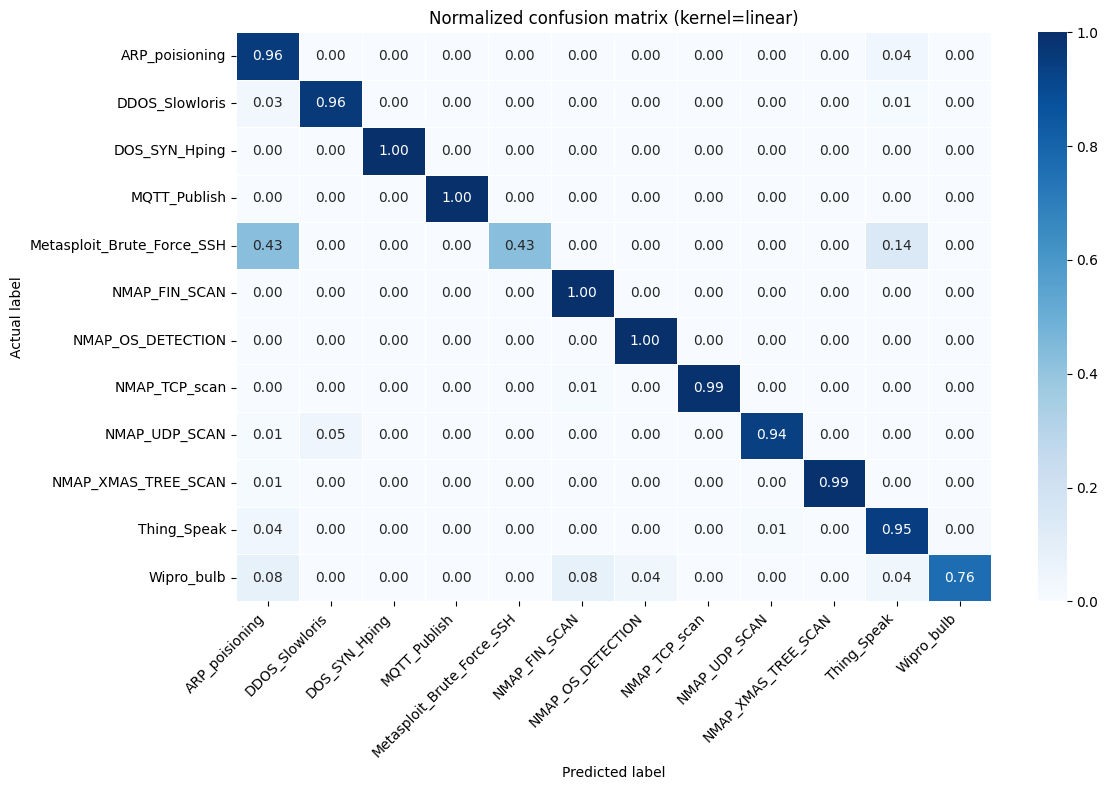


Kernel: poly
Best parameters: {'svc__C': 10, 'svc__gamma': 0.01}

Classification report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.94      0.95      0.95      1550
            DDOS_Slowloris       0.78      0.97      0.87       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.75      0.43      0.55         7
             NMAP_FIN_SCAN       0.60      1.00      0.75         6
         NMAP_OS_DETECTION       0.99      1.00      1.00       400
             NMAP_TCP_scan       0.99      0.99      0.99       200
             NMAP_UDP_SCAN       1.00      0.93      0.97       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.96      0.95      0.96      1622
                Wipro_bulb       0.66      0.69      0.67        51

                  accura

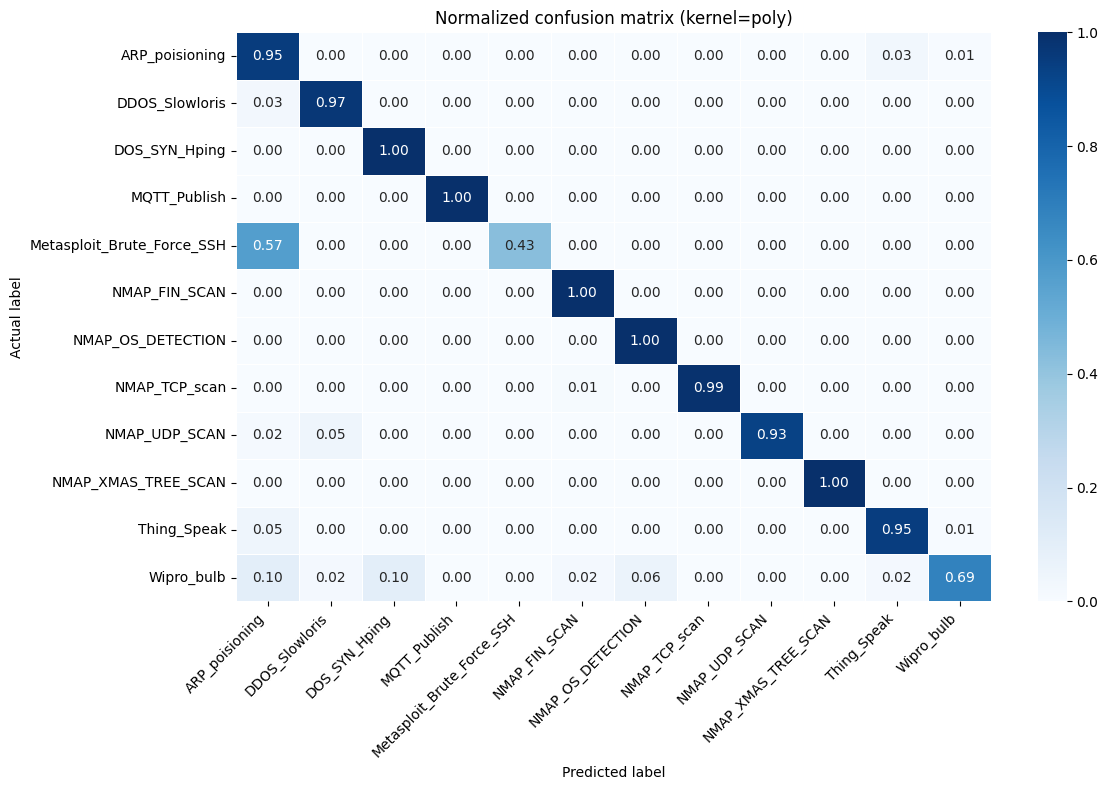


Kernel: rbf
Best parameters: {'svc__C': 10, 'svc__gamma': 0.01}

Classification report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.92      0.97      0.94      1550
            DDOS_Slowloris       0.80      0.97      0.88       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      0.99      1.00       829
Metasploit_Brute_Force_SSH       1.00      0.43      0.60         7
             NMAP_FIN_SCAN       0.60      1.00      0.75         6
         NMAP_OS_DETECTION       0.99      1.00      1.00       400
             NMAP_TCP_scan       0.99      0.99      0.99       200
             NMAP_UDP_SCAN       1.00      0.93      0.96       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.98      0.93      0.96      1622
                Wipro_bulb       0.67      0.59      0.62        51

                  accurac

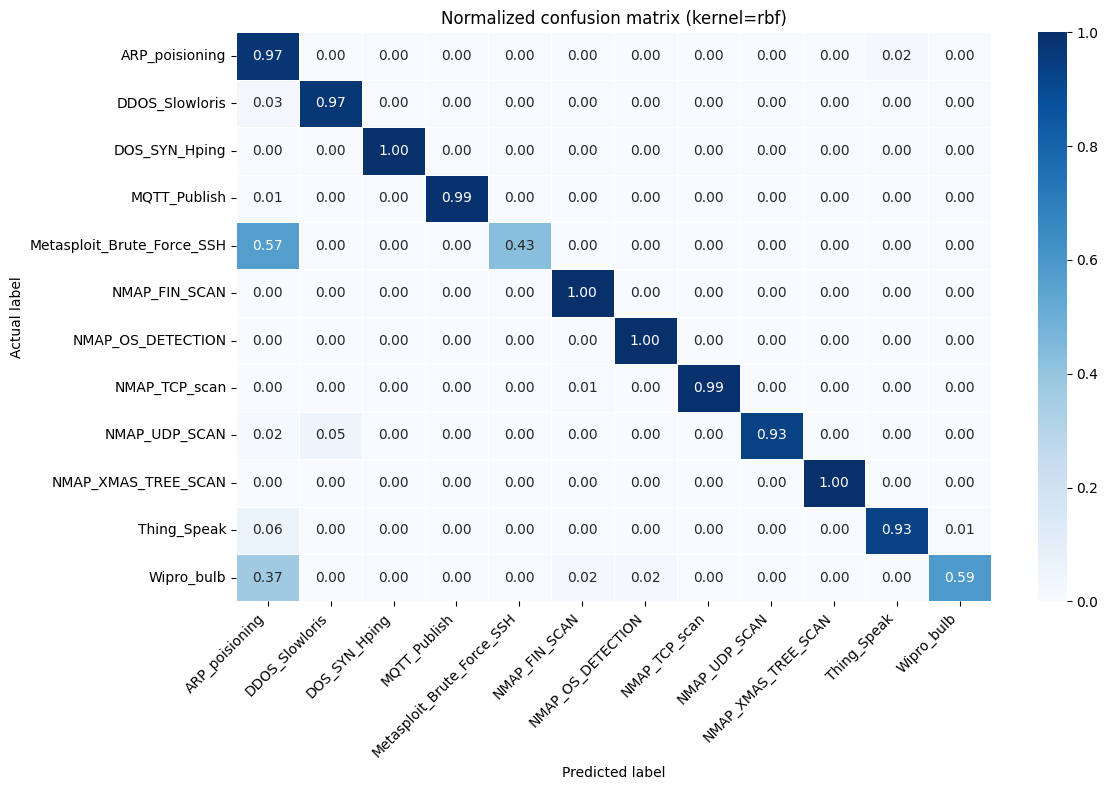


Kernel: sigmoid
Best parameters: {'svc__C': 10, 'svc__gamma': 0.001}

Classification report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.91      0.72      0.80      1550
            DDOS_Slowloris       0.69      0.83      0.75       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      0.99      0.99       829
Metasploit_Brute_Force_SSH       0.33      0.43      0.38         7
             NMAP_FIN_SCAN       0.46      1.00      0.63         6
         NMAP_OS_DETECTION       0.98      1.00      0.99       400
             NMAP_TCP_scan       0.86      0.99      0.92       200
             NMAP_UDP_SCAN       0.92      0.93      0.92       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.83      0.90      0.86      1622
                Wipro_bulb       0.21      0.67      0.32        51

                  ac

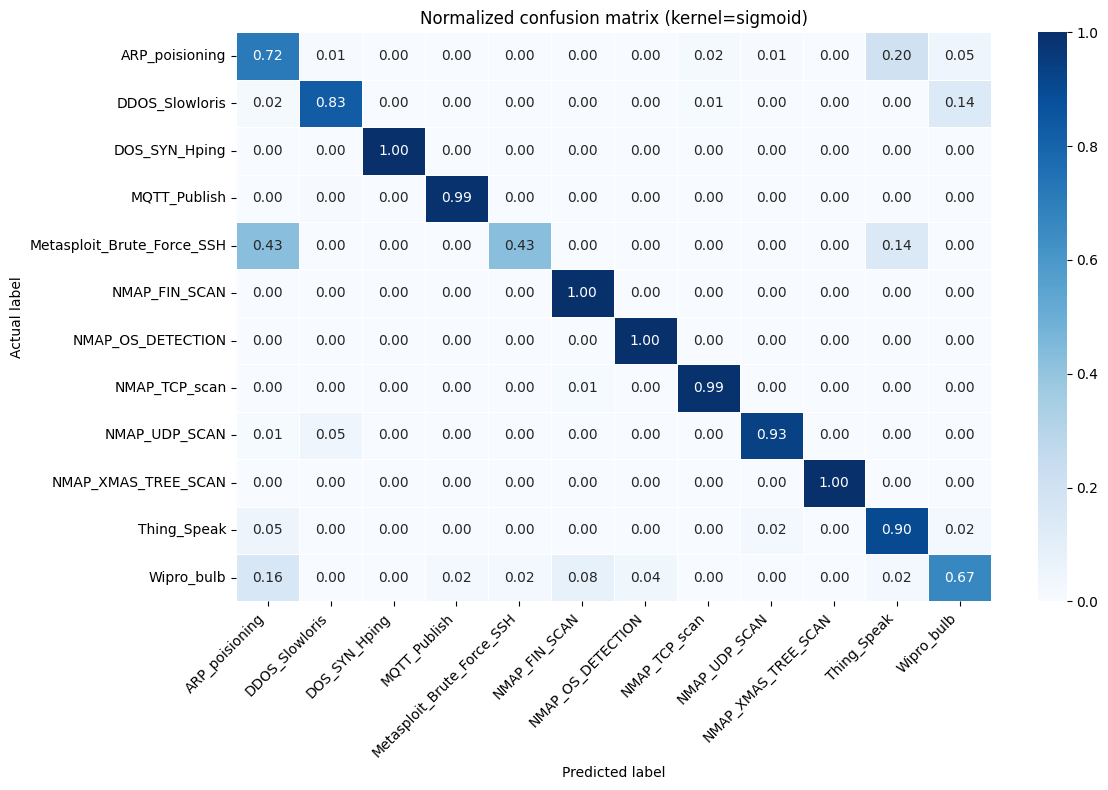


Comparison of kernels:
    kernel  accuracy  precision    recall  f1_score
0   linear  0.991147   0.886482  0.914317  0.887796
1     poly  0.990944   0.888837  0.908582  0.889900
2      rbf  0.990984   0.911790  0.900491  0.891334
3  sigmoid  0.972182   0.765635  0.871081  0.797588


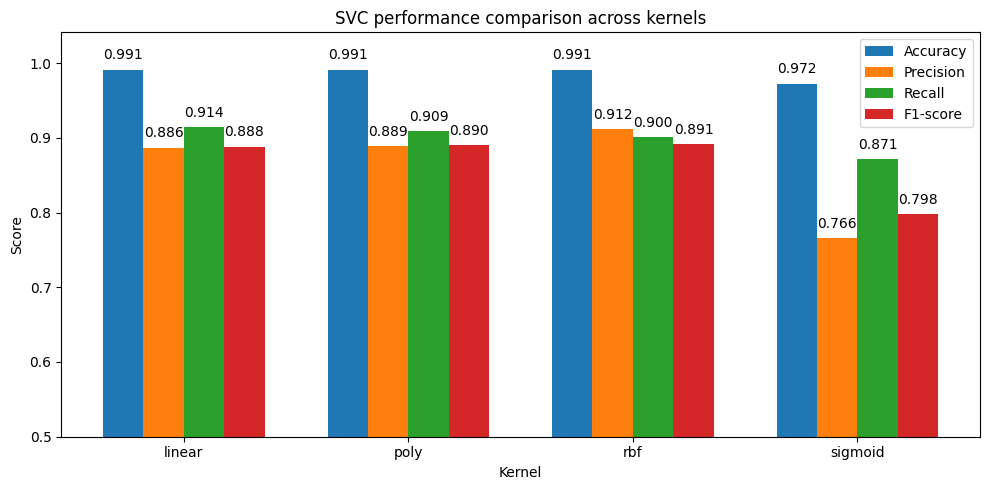


Best kernel based on accuracy: linear

Training SVC with kernel=linear, C=0.1
  Accuracy : 0.9823
  Precision: 0.8683
  Recall   : 0.9034
  F1-score : 0.8756

Training SVC with kernel=linear, C=1
  Accuracy : 0.9902
  Precision: 0.8873
  Recall   : 0.9136
  F1-score : 0.8876

Training SVC with kernel=linear, C=10
  Accuracy : 0.9911
  Precision: 0.8865
  Recall   : 0.9143
  F1-score : 0.8878

Comparison for different C values (kernel = linear):
   C_value  accuracy  precision    recall  f1_score
0      0.1  0.982294   0.868265  0.903430  0.875555
1      1.0  0.990213   0.887332  0.913574  0.887608
2     10.0  0.991147   0.886482  0.914317  0.887796


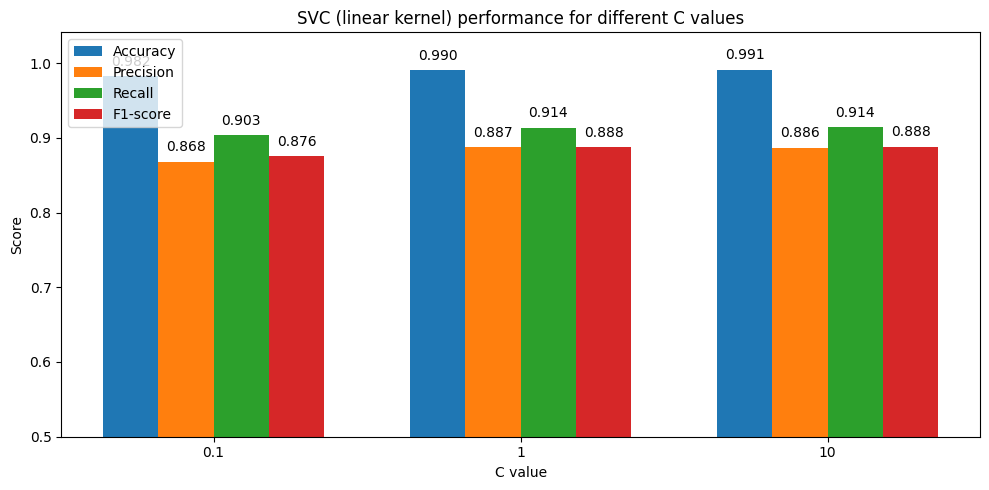

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

print("Train shape:", X_train2.shape)
print("Test shape :", X_test2.shape)

max_train_samples = 123117  # change if you want more/less

if X_train2.shape[0] > max_train_samples:
    X_train_svc, _, y_train_svc, _ = train_test_split(
        X_train2,
        Y_train2,
        train_size=max_train_samples,
        random_state=0,
        stratify=Y_train2
    )
else:
    X_train_svc, y_train_svc = X_train2, Y_train2

# Not to trigger the warning
unique_classes, counts = np.unique(y_train_svc, return_counts=True)
min_count = counts.min()

if min_count < 2:
    raise ValueError(
        f"At least one class in y_train_svc has < 2 samples (min={min_count}). "
        "Cannot safely perform cross-validation."
    )

cv_folds = min(3, min_count)


# SVC for different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_models = {}

# containers for metric comparison across kernels
kernel_names = []
acc_list = []
prec_list = []
rec_list = []
f1_list = []

for kernel in kernels:
    print("\n" + "="*70)
    print(f"Kernel: {kernel}")
    print("="*70)

    svc = SVC(kernel=kernel, class_weight='balanced')
    model = make_pipeline(StandardScaler(), svc)

    # parameter grid
    if kernel == 'linear':
        param_grid = {
            'svc__C': [0.1, 1, 10]
        }
    else:
        param_grid = {
            'svc__C': [0.1, 1, 10],
            'svc__gamma': [0.01, 0.001]
        }

    grid = GridSearchCV(
        model,
        param_grid,
        cv=cv_folds,
        n_jobs=-1,
        verbose=0
    )

    # fit on subsampled training data
    grid.fit(X_train_svc, y_train_svc)

    print("Best parameters:", grid.best_params_)
    best_model = grid.best_estimator_
    best_models[kernel] = best_model

    # predict on full test set
    y_pred = best_model.predict(X_test2)

    # classification report
    print("\nClassification report:")
    print(classification_report(Y_test2, y_pred, target_names=class_names))

    # overall metrics per kernel
    acc = accuracy_score(Y_test2, y_pred)
    prec = precision_score(Y_test2, y_pred, average='macro', zero_division=0)
    rec = recall_score(Y_test2, y_pred, average='macro', zero_division=0)
    f1m = f1_score(Y_test2, y_pred, average='macro', zero_division=0)

    kernel_names.append(kernel)
    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1m)

    print(f"\nOverall metrics for kernel={kernel}:")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1m:.4f}")

    # Confusion matrix
    cm = confusion_matrix(Y_test2, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0, vmax=1,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        linecolor="white"
    )

    plt.title(f"Normalized confusion matrix (kernel={kernel})")
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Kernel comparison: accuracy / precision / recall / F1
results_df = pd.DataFrame({
    'kernel': kernel_names,
    'accuracy': acc_list,
    'precision': prec_list,
    'recall': rec_list,
    'f1_score': f1_list
})

print("\nComparison of kernels:")
print(results_df)

x = np.arange(len(kernel_names))
width = 0.18

acc_color  = "tab:blue"
prec_color = "tab:orange"
rec_color  = "tab:green"
f1_color   = "tab:red"

plt.figure(figsize=(10, 5))

bars_acc  = plt.bar(x - 1.5*width, results_df['accuracy'],
                    width, label='Accuracy', color=acc_color)
bars_prec = plt.bar(x - 0.5*width, results_df['precision'],
                    width, label='Precision', color=prec_color)
bars_rec  = plt.bar(x + 0.5*width, results_df['recall'],
                    width, label='Recall', color=rec_color)
bars_f1   = plt.bar(x + 1.5*width, results_df['f1_score'],
                    width, label='F1-score', color=f1_color)

plt.xticks(x, kernel_names)
plt.ylabel('Score')
plt.xlabel('Kernel')
plt.title('SVC performance comparison across kernels')

all_vals = (list(results_df['accuracy']) +
            list(results_df['precision']) +
            list(results_df['recall']) +
            list(results_df['f1_score']))
top = max(all_vals) + 0.05
plt.ylim(0.5, top)

plt.legend()

def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

add_labels(bars_acc)
add_labels(bars_prec)
add_labels(bars_rec)
add_labels(bars_f1)

plt.tight_layout()
plt.show()

# Comparison for different C values
# using the best kernel found above
best_kernel_idx = results_df['accuracy'].idxmax()
best_kernel = results_df.loc[best_kernel_idx, 'kernel']
print(f"\nBest kernel based on accuracy: {best_kernel}")

C_values = [0.1, 1, 10]

C_acc_list = []
C_prec_list = []
C_rec_list = []
C_f1_list = []

for C in C_values:
    print(f"\nTraining SVC with kernel={best_kernel}, C={C}")

    svc = SVC(kernel=best_kernel, C=C, class_weight='balanced')
    model_C = make_pipeline(StandardScaler(), svc)

    # fit on the same subsampled training data
    model_C.fit(X_train_svc, y_train_svc)

    y_pred_C = model_C.predict(X_test2)

    acc_C  = accuracy_score(Y_test2, y_pred_C)
    prec_C = precision_score(Y_test2, y_pred_C, average='macro', zero_division=0)
    rec_C  = recall_score(Y_test2, y_pred_C, average='macro', zero_division=0)
    f1_C   = f1_score(Y_test2, y_pred_C, average='macro', zero_division=0)

    C_acc_list.append(acc_C)
    C_prec_list.append(prec_C)
    C_rec_list.append(rec_C)
    C_f1_list.append(f1_C)

    print(f"  Accuracy : {acc_C:.4f}")
    print(f"  Precision: {prec_C:.4f}")
    print(f"  Recall   : {rec_C:.4f}")
    print(f"  F1-score : {f1_C:.4f}")

# C comparison table
C_results_df = pd.DataFrame({
    'C_value': C_values,
    'accuracy': C_acc_list,
    'precision': C_prec_list,
    'recall': C_rec_list,
    'f1_score': C_f1_list
})

print("\nComparison for different C values (kernel = "
      f"{best_kernel}):")
print(C_results_df)

# C comparison bar plot
xC = np.arange(len(C_values))
widthC = 0.18

plt.figure(figsize=(10, 5))

bars_acc_C  = plt.bar(xC - 1.5*widthC, C_results_df['accuracy'],
                      widthC, label='Accuracy', color=acc_color)
bars_prec_C = plt.bar(xC - 0.5*widthC, C_results_df['precision'],
                      widthC, label='Precision', color=prec_color)
bars_rec_C  = plt.bar(xC + 0.5*widthC, C_results_df['recall'],
                      widthC, label='Recall', color=rec_color)
bars_f1_C   = plt.bar(xC + 1.5*widthC, C_results_df['f1_score'],
                      widthC, label='F1-score', color=f1_color)

plt.xticks(xC, [str(c) for c in C_values])
plt.ylabel('Score')
plt.xlabel('C value')
plt.title(f'SVC ({best_kernel} kernel) performance for different C values')

all_vals_C = (list(C_results_df['accuracy']) +
              list(C_results_df['precision']) +
              list(C_results_df['recall']) +
              list(C_results_df['f1_score']))
topC = max(all_vals_C) + 0.05
plt.ylim(0.5, topC)

plt.legend()

add_labels(bars_acc_C)
add_labels(bars_prec_C)
add_labels(bars_rec_C)
add_labels(bars_f1_C)

plt.tight_layout()
plt.show()


**Neural Network (Fully Connected)**

Using device: cpu
Train tensor shape: torch.Size([98493, 93])
Val tensor shape  : torch.Size([24624, 93])
IoTNet(
  (net): Sequential(
    (0): Linear(in_features=93, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=12, bias=True)
  )
)

Per-layer parameter table:
Layer Shape (in->out)  Param count
net.0        93 → 128        12032
net.3        128 → 64         8256
net.6         64 → 12          780

Model size summary:
  Total parameters    : 21,068
  Trainable parameters: 21,068
  Approx. memory      : 0.08 MB

Epoch   1/100 | Train Loss: 0.2549 | Train Acc: 0.9409 | Val Loss: 0.0659 | Val Acc: 0.9781
Epoch  20/100 | Train Loss: 0.0167 | Train Acc: 0.9947 | Val Loss: 0.0176 | Val Acc: 0.9946
Epoch  40/100 | Train Loss: 0.0119 | Train Acc: 0.9959 | Val Loss: 0.0165 | Val Acc: 0.9954
Epoch  

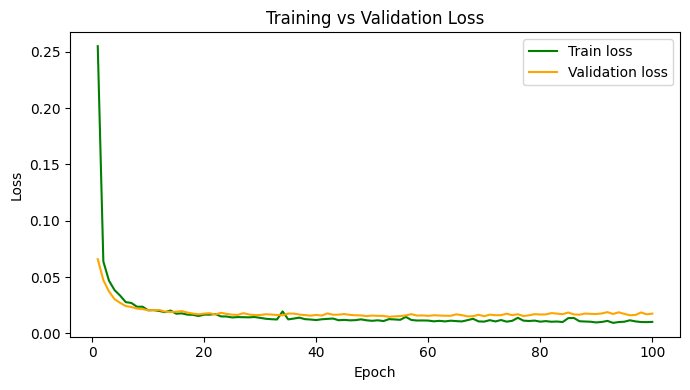

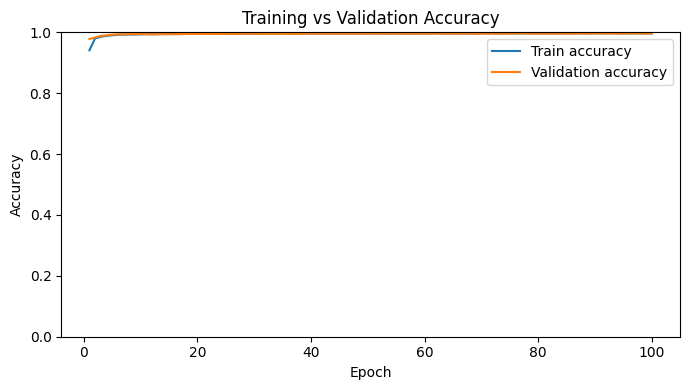

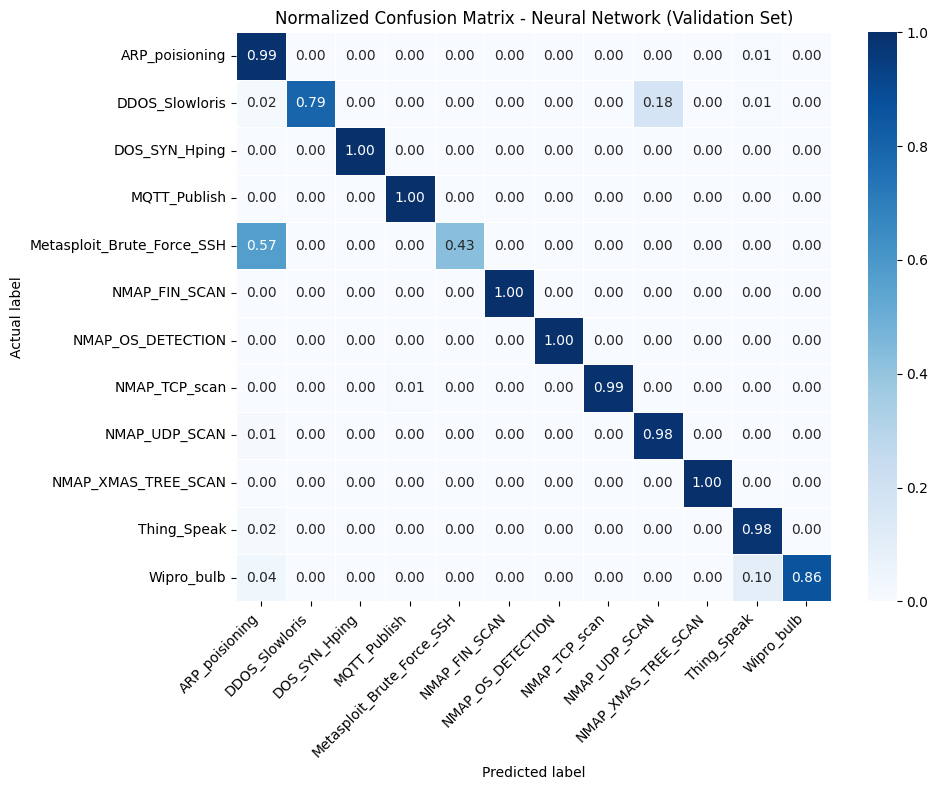

                            precision    recall  f1-score   support

            ARP_poisioning       0.97      0.99      0.98      1550
            DDOS_Slowloris       1.00      0.79      0.89       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.75      0.43      0.55         7
             NMAP_FIN_SCAN       1.00      1.00      1.00         6
         NMAP_OS_DETECTION       1.00      1.00      1.00       400
             NMAP_TCP_scan       1.00      0.99      0.99       200
             NMAP_UDP_SCAN       0.96      0.98      0.97       518
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       402
               Thing_Speak       0.99      0.98      0.98      1622
                Wipro_bulb       0.98      0.86      0.92        51

                  accuracy                           1.00     24624
                 macro avg       0.97      0.9

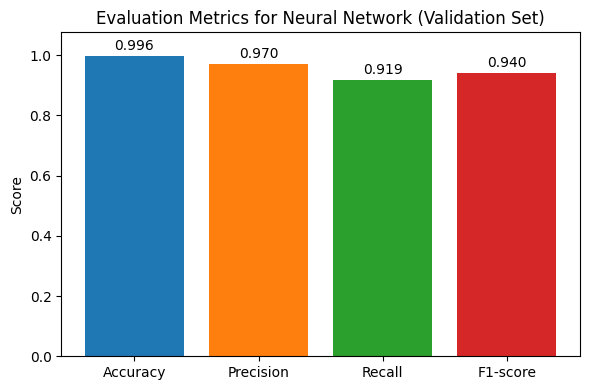

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# We reuse the preprocessed train/validation split from earlier
# (X_train2_std, X_test2_std, Y_train2, Y_test2).

# Convert numpy/pandas data to PyTorch tensors
X_train_tensor = torch.tensor(X_train2_std, dtype=torch.float32)
y_train_array  = Y_train2.values if hasattr(Y_train2, "values") else Y_train2
y_train_tensor = torch.tensor(y_train_array, dtype=torch.long)

X_val_tensor = torch.tensor(X_test2_std, dtype=torch.float32)
y_val_array  = Y_test2.values if hasattr(Y_test2, "values") else Y_test2
y_val_tensor = torch.tensor(y_val_array, dtype=torch.long)

print("Train tensor shape:", X_train_tensor.shape)
print("Val tensor shape  :", X_val_tensor.shape)

# Build TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

# For compatibility with the existing code that uses X_tensor.shape[1]
X_tensor = X_train_tensor

# ============================
# 5. Neural network model
# ============================
input_dim   = X_tensor.shape[1]   # 92 features (or whatever your feature count is)
hidden1     = 128
hidden2     = 64
num_classes = len(class_names)    # 12

class IoTNet(nn.Module):
    def __init__(self, in_dim, h1, h2, out_dim):
        super(IoTNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        return self.net(x)

model = IoTNet(input_dim, hidden1, hidden2, num_classes).to(device)
print(model)

# ---- Per-layer parameter table + model size ----
layer_rows = []
for name, module in model.named_modules():
    if isinstance(module, nn.Linear):
        n_params = sum(p.numel() for p in module.parameters())
        in_features = module.in_features
        out_features = module.out_features
        layer_rows.append({
            "Layer": name,
            "Shape (in->out)": f"{in_features} → {out_features}",
            "Param count": n_params
        })

layer_df = pd.DataFrame(layer_rows)
total_params = layer_df["Param count"].sum()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
approx_size_mb = total_params * 4 / (1024**2)  # float32 = 4 bytes

print("\nPer-layer parameter table:")
print(layer_df.to_string(index=False))

print("\nModel size summary:")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Approx. memory      : {approx_size_mb:.2f} MB\n")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================
# 6. Training loop
# ============================
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


num_epochs = 100

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

start_time = time.time()  # ----- start timer -----

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc  = correct / total

    epoch_val_loss, epoch_val_acc = evaluate(val_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

end_time = time.time()
elapsed = end_time - start_time
print(f"\nTraining completed in {elapsed:.2f} seconds.")

# ============================
# 7. Final metrics
# ============================
final_train_loss = train_losses[-1]
final_val_loss   = val_losses[-1]
final_train_acc  = train_accs[-1]
final_val_acc    = val_accs[-1]

print("\nFinal results after 100 epochs:")
print(f"Training loss      : {final_train_loss:.4f}")
print(f"Validation loss    : {final_val_loss:.4f}")
print(f"Training accuracy  : {final_train_acc:.4f}")
print(f"Validation accuracy: {final_val_acc:.4f}")

# ============================
# 8. Plots: loss & accuracy
# ============================
epochs = range(1, num_epochs + 1)

# Loss curves
plt.figure(figsize=(7,4))
plt.plot(epochs, train_losses, label="Train loss", color='green')
plt.plot(epochs, val_losses,   label="Validation loss", color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy curves
plt.figure(figsize=(7,4))
plt.plot(epochs, train_accs, label="Train accuracy",color='green')
plt.plot(epochs, val_accs,   label="Validation accuracy",color='orange')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

# ============================
# 9. Confusion matrix on validation set
# ============================
model.eval()
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        outputs = model(xb)
        preds = outputs.argmax(dim=1)

        all_true.extend(yb.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

y_true = np.array(all_true)
y_pred = np.array(all_pred)

cm = confusion_matrix(y_true, y_pred)

# Normalized confusion matrix
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Normalized Confusion Matrix - Neural Network (Validation Set)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================
# 10. Classification report
# ============================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)
print(report)

# ============================
# 11. Evaluation metrics & bar chart
# ============================
val_accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("\nNeural Network metrics on validation set:")
print(f"  Accuracy           : {val_accuracy:.4f}")
print(f"  Precision (macro)  : {precision_macro:.4f}")
print(f"  Recall (macro)     : {recall_macro:.4f}")
print(f"  F1-score (macro)   : {f1_macro:.4f}")

metrics_names  = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [val_accuracy, precision_macro, recall_macro, f1_macro]

plt.figure(figsize=(6,4))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
bars = plt.bar(metrics_names, metrics_values, color=colors)
plt.ylim(0.0, max(metrics_values) + 0.08)
plt.ylabel("Score")
plt.title("Evaluation Metrics for Neural Network (Validation Set)")

# add value labels a bit above each bar
for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,        # slightly above bar
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()
